<a href="https://colab.research.google.com/github/oyejam/oyejam/blob/main/Lab%201%20%E2%80%93%20Dynamic%20Model%20of%20a%20Multi-Link%20Manipulator%20(UR5).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Fix environment (run once)
!pip install "numpy<2" roboticstoolbox-python spatialmath-python --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 3.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 24.9 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 38.8 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 10.9 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.7/114.7 MB 5.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 57.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.5/193.5 kB 9.2 MB/s eta 0:00:

#Import

In [2]:
!pip uninstall -y numpy
!pip install "numpy<2"
!pip install --force-reinstall roboticstoolbox-python spatialmath-python

Found existing installation: numpy 1.26.4
Uninstalling numpy-1.26.4:
  Successfully uninstalled numpy-1.26.4
  Using cached numpy-1.26.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (61 kB)
Using cached numpy-1.26.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (18.0 MB)
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
pytensor 2.38.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
opencv-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
opencv-contrib-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
tobler 0.14.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
xarray-einstats 0.10.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
shap 0.51.0 

  Using cached roboticstoolbox_python-1.1.1-cp312-cp312-linux_x86_64.whl
  Using cached spatialmath_python-1.1.15-py3-none-any.whl.metadata (17 kB)
  Using cached spatialgeometry-1.1.0-cp312-cp312-linux_x86_64.whl
  Using cached pgraph_python-0.6.3-py3-none-any.whl.metadata (7.5 kB)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.1/62.1 kB 4.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 4.0 MB/s eta 0:00:00
  Using cached ansitable-0.11.5-py3-none-any.whl.metadata (28 kB)
  Using cached swift_sim-1.1.0-cp312-cp312-linux_x86_64.whl
  Using cached rtb_data-1.0.1-py3-none-any.whl
  Using cached progress-1.6.1-py3-none-any.whl.metadata (4.3 kB)
  Using cached pre_commit-4.5.1-py2.py3-none-any.whl.metadata (1.2 kB)
  Using cached colored-2.3.2-py3-none-any.whl.metadata (4.5 kB)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.5/117.5 kB 9.4 MB/s eta 0:00:00
ERROR: Operation cancelled by user
Traceback (most recent call last):
  File "/usr/local/lib/python3.1

In [1]:
import numpy as np
import roboticstoolbox as rtb
import matplotlib.pyplot as plt
from math import pi

In [2]:
#load manipulator

import roboticstoolbox as rtb

robot = rtb.models.DH.UR5()
print(robot)

DHRobot: UR5 (by Universal Robotics), 6 joints (RRRRRR), dynamics, standard DH parameters
┌─────┬─────────┬─────────┬────────┐
│ θⱼ  │   dⱼ    │   aⱼ    │   ⍺ⱼ   │
├─────┼─────────┼─────────┼────────┤
│  q1 │ 0.08946 │       0 │  90.0° │
│  q2 │       0 │  -0.425 │   0.0° │
│  q3 │       0 │ -0.3922 │   0.0° │
│  q4 │  0.1091 │       0 │  90.0° │
│  q5 │ 0.09465 │       0 │ -90.0° │
│  q6 │  0.0823 │       0 │   0.0° │
└─────┴─────────┴─────────┴────────┘

┌──┬──┐
└──┴──┘

┌──────┬───────┬─────┬─────┬─────┬──────┬─────┐
│ name │ q0    │ q1  │ q2  │ q3  │ q4   │ q5  │
├──────┼───────┼─────┼─────┼─────┼──────┼─────┤
│   qr │  180° │  0° │  0° │  0° │  90° │  0° │
│   qz │  0°   │  0° │  0° │  0° │  0°  │  0° │
└──────┴───────┴─────┴─────┴─────┴──────┴─────┘



In [3]:
#Extract DH Parameters

for i, link in enumerate(robot.links):
    print(f"Link {i+1}:")
    print(f"theta = {link.theta}, d = {link.d}, a = {link.a}, alpha = {link.alpha}")

Link 1:
theta = 0.0, d = 0.089459, a = 0, alpha = 1.5707963267948966
Link 2:
theta = 0.0, d = 0, a = -0.425, alpha = 0.0
Link 3:
theta = 0.0, d = 0, a = -0.39225, alpha = 0.0
Link 4:
theta = 0.0, d = 0.10915, a = 0, alpha = 1.5707963267948966
Link 5:
theta = 0.0, d = 0.09465, a = 0, alpha = -1.5707963267948966
Link 6:
theta = 0.0, d = 0.0823, a = 0, alpha = 0.0


In [5]:
#Dynamic Parameters

for i in range(len(robot.links)):
    print(robot.links[i].dyn())

m     =       3.7 
r     =         0   -0.026   0.0019 
        |        0        0        0 | 
I     = |        0        0        0 | 
        |        0        0        0 | 
Jm    =         0 
B     =         0 
Tc    =         0(+)        0(-) 
G     =         1 
qlim  =         0 to        0
m     =       8.4 
r     =      0.21        0     0.11 
        |        0        0        0 | 
I     = |        0        0        0 | 
        |        0        0        0 | 
Jm    =         0 
B     =         0 
Tc    =         0(+)        0(-) 
G     =         1 
qlim  =         0 to        0
m     =       2.3 
r     =      0.15        0    0.026 
        |        0        0        0 | 
I     = |        0        0        0 | 
        |        0        0        0 | 
Jm    =         0 
B     =         0 
Tc    =         0(+)        0(-) 
G     =         1 
qlim  =         0 to        0
m     =       1.2 
r     =         0  -0.0018    0.016 
        |        0        0        0 | 
I     = |    

In [21]:
# ================================
# FIX INCOMPLETE DYNAMIC PARAMETERS
# ================================

for i, link in enumerate(robot.links):

    # --- Mass (already valid, keep it) ---
    link.m = link.m

    # --- Center of Mass (already valid) ---
    link.r = link.r

    # --- Inertia tensor (FIX: was zero) ---
    link.I = [0.01, 0.01, 0.01, 0, 0, 0]

    # --- Motor inertia (FIX) ---
    link.Jm = 0.0001

    # --- Viscous friction (FIX) ---
    link.B = 0.001

    # --- Coulomb friction (FIX) ---
    link.Tc = [0.05, -0.05]

    # --- Gear ratio (reasonable assumption) ---
    link.G = 50

    # --- Joint limits (FIX: was zero) ---
    link.qlim = [-np.pi, np.pi]

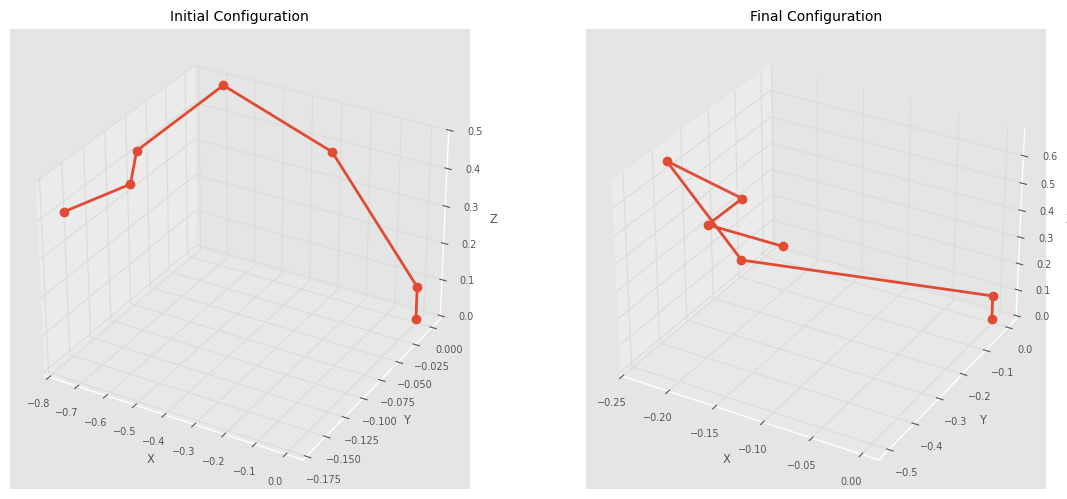

In [23]:
# ================================
# CONFIGURATIONS (Start and End Position)
# ================================
q_start = [0, -pi/4, pi/6, 0, pi/4, 0]
q_end   = [pi/3, -pi/6, -pi/4, pi/4, -pi/3, pi/6]

# ================================
# FUNCTION TO GET JOINT POSITIONS
# ================================
def get_joint_positions(robot, q):
    T = robot.fkine_all(q)  # forward kinematics for all joints
    points = np.array([Ti.t for Ti in T])  # extract positions
    return points

# ================================
# GET POSITIONS
# ================================
p_start = get_joint_positions(robot, q_start)
p_end   = get_joint_positions(robot, q_end)

# ================================
# PLOT FUNCTION
# ================================
def plot_robot(ax, points, title):
    ax.plot(points[:,0], points[:,1], points[:,2], '-o', linewidth=2)
    ax.set_title(title)
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')
    ax.grid(True)

# ================================
# PLOT BOTH CONFIGURATIONS
# ================================
fig = plt.figure(figsize=(12,5))

ax1 = fig.add_subplot(121, projection='3d')
plot_robot(ax1, p_start, "Initial Configuration")

ax2 = fig.add_subplot(122, projection='3d')
plot_robot(ax2, p_end, "Final Configuration")

plt.tight_layout()
plt.show()

In [24]:
# Trajectory Planning

N = 100
time = np.linspace(0, 5, N)

tr = rtb.jtraj(q_start, q_end, time)

In [25]:
#INVERSE DYNAMICS

tau_full = robot.rne(tr.q, tr.qd, tr.qdd) #Case 1: Full dynamics

tau_quasi = robot.rne(tr.q, tr.qd, np.zeros_like(tr.qdd)) #Case 2: Quasi-static

tau_static = robot.rne(tr.q,
                      np.zeros_like(tr.qd),
                      np.zeros_like(tr.qdd))    #Case 3: Static

In [26]:
# M, C, G MATRICES

M = robot.inertia(tr.q)
C = robot.coriolis(tr.q, tr.qd)
G = robot.gravload(tr.q)

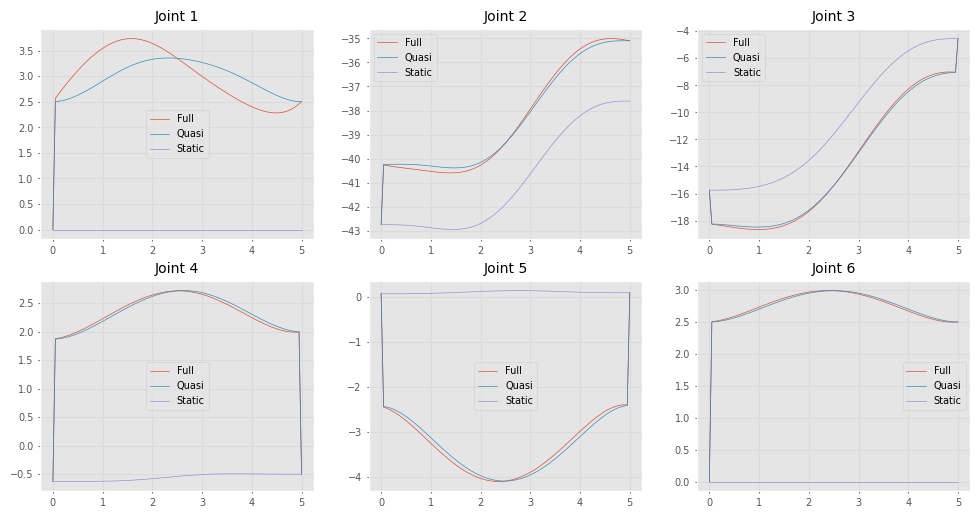

In [27]:
#Plot

plt.figure(figsize=(12,6))

for i in range(6):
    plt.subplot(2,3,i+1)
    plt.plot(time, tau_full[:,i], label="Full")
    plt.plot(time, tau_quasi[:,i], label="Quasi")
    plt.plot(time, tau_static[:,i], label="Static")
    plt.title(f"Joint {i+1}")
    plt.grid(True)
    plt.legend()

plt.show()